### 1. The Gaussian (Normal) Distribution: The "Safe" Market

In a Gaussian world, price movements are driven by a high number of small, independent events that average out. This is the "Bell Curve".

**Relationship to Time Series:** It assumes that extreme events (market crashes or massive spikes) are so statistically rare that they are practically impossible. It creates a "Random Walk" where the price wiggles but never truly "jumps".

**The Flaw:** If you use this for financial time series, your AI will be "blind" to volatility. It learns that if the price drops 1%, it is almost guaranteed to stay within that range, leading to catastrophic losses when a real-world shock occurs.

### 2. The Student's t-Distribution: The "Real" Market

This distribution introduces Kurtosis, which in financial terms means "Fat Tails." It is defined by "Degrees of Freedom" (df); as df decreases, the tails get "fatter".

**Relationship to Time Series:** It acknowledges that "Black Swan" events—sudden, massive moves—happen far more frequently than a standard bell curve suggests.

**The Benefit:** By using a Student's t-distribution, you are injecting "shocks" into the price path. This forces an RL agent to respect risk management because it knows a massive outlier could happen at any moment.

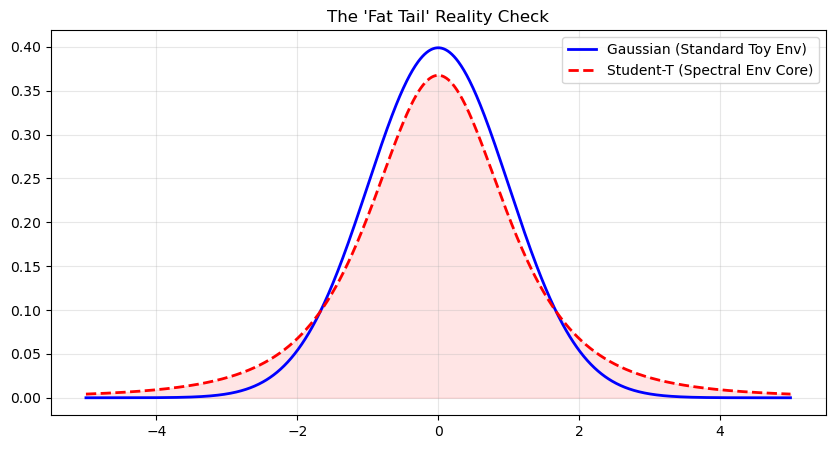

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, t

# 1. Visualize the Math (For the "Visual" overlay in the script)
def plot_distribution_comparison():
    x = np.linspace(-5, 5, 1000)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x, norm.pdf(x), label='Gaussian (Standard Toy Env)', lw=2, color='blue')
    plt.plot(x, t.pdf(x, df=3), label='Student-T (Spectral Env Core)', lw=2, color='red', ls='--')
    
    plt.fill_between(x, t.pdf(x, df=3), alpha=0.1, color='red')
    plt.title("The 'Fat Tail' Reality Check")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_distribution_comparison()

###  Force a Black Swan Event

In [1]:
import numpy as np
from spectral_env_core import SpectralTradingEnv

class BlackSwanDirector(SpectralTradingEnv):
    """A rigged version of the environment specifically for filming shocks."""
    
    def _generate_brownian_path(self):
        # Generate a standard path first
        path = super()._generate_brownian_path()
        
        # --- THE 'DIRECTOR'S CUT' ---
        # At 50% through the episode, we force a 15% flash crash 
        # to simulate a Fat Tail event (df=3 style)
        crash_point = self.num_steps // 2
        path[crash_point:] = path[crash_point:] * 0.85 
        
        return path

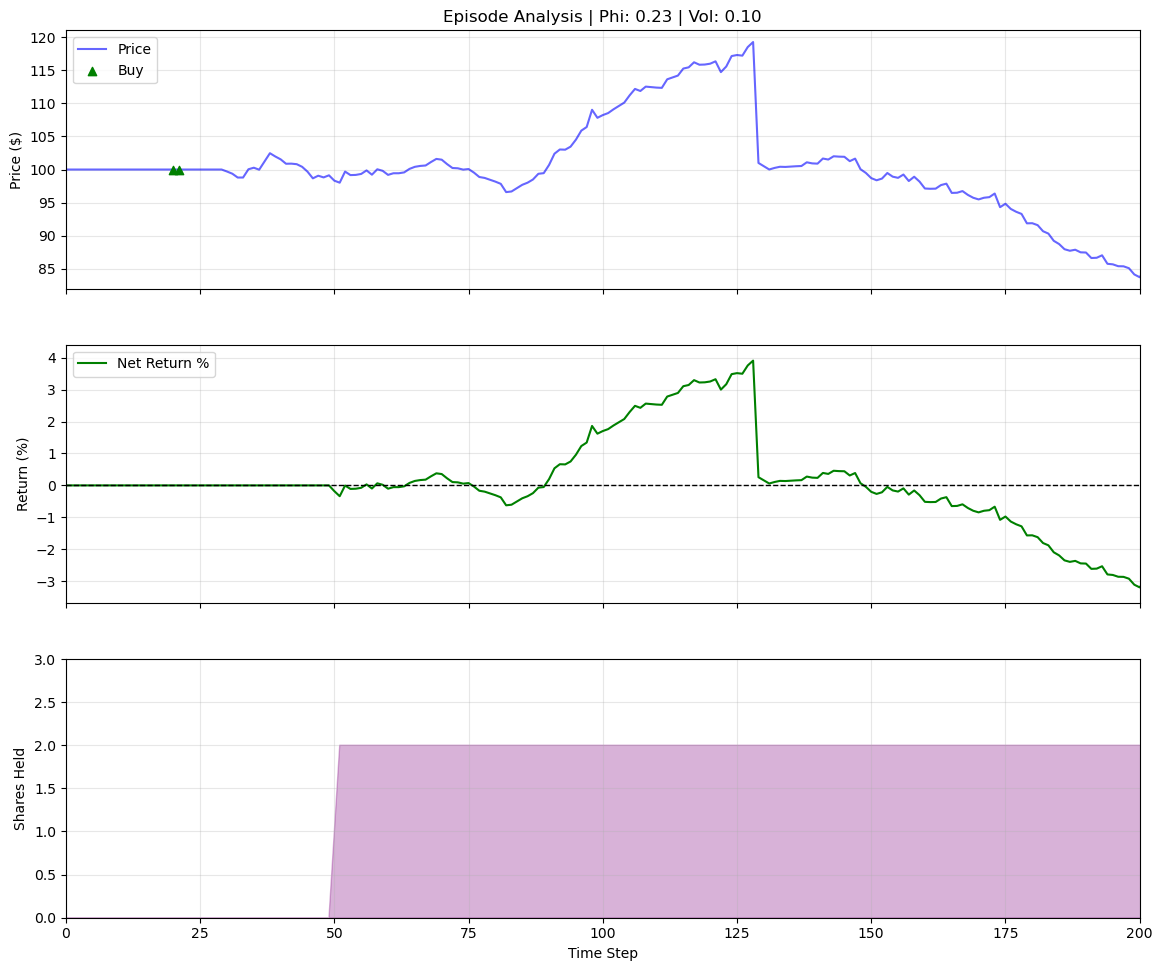

In [2]:
# Initialize the 'Rigged' environment for the video
env_film = BlackSwanDirector(render_mode='human', num_steps=200)
obs, info = env_film.reset()

for step in range(env_film.num_steps):
    if step < 10:
        action = 0 
    elif step == 10:
        action = 1 # Force the buy
    else:
        action = 0 # Force it to HOLD through the crash
        
    obs, reward, done, truncated, info = env_film.step(action)
    env_film.render()
    if done: break
        
    obs, reward, done, truncated, info = env_film.step(action)
    
    env_film.render()
    
    if done:
        break

In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback, StopTrainingOnRewardThreshold
from spectral_env_core import SpectralTradingEnv

# 1. Configuration
# df=3: Extreme Kurtosis (High risk, frequent "Black Swans")
# df=100: Approaches a Normal Distribution (Low risk, very stable)

env_kwargs = {
    "num_steps": 200,
    "time_total": 1.0,
    "initial_price": 100.0,
    "starting_cash": 1200,
    "volatility": 0.05,
    "df" : 3,
    "transaction_cost_pct": 0.001,
    "drift": 0,
    "max_shares": 10
}

eval_env = SpectralTradingEnv(**env_kwargs, render_mode=None)

    # --- 4. Train the Agent ---
print("Starting Training Loop...")

model = PPO(
        "MlpPolicy", 
        eval_env, 
        verbose=1, 
        device='cpu',
        n_steps=2048,          # Number of steps to run for each environment per update
        batch_size=64,         # Minibatch size for each gradient update
        gamma=0.99,            # Discount factor (0.99 is standard for long-term rewards)
        ent_coef=0.05,         # Keeps the agent exploring
        learning_rate=0.0003   # Standard starting rate for PPO
    )
model.learn(total_timesteps=1000000)

Starting Training Loop...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 200      |
|    ep_rew_mean     | -36.2    |
| time/              |          |
|    fps             | 4562     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 200         |
|    ep_rew_mean          | -43.2       |
| time/                   |             |
|    fps                  | 2782        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.007394636 |
|    clip_fraction        | 0.011       |
|    clip_range           | 0.2     

Testing Model: model on Black Swan Rigged Path...
Episode Finished.


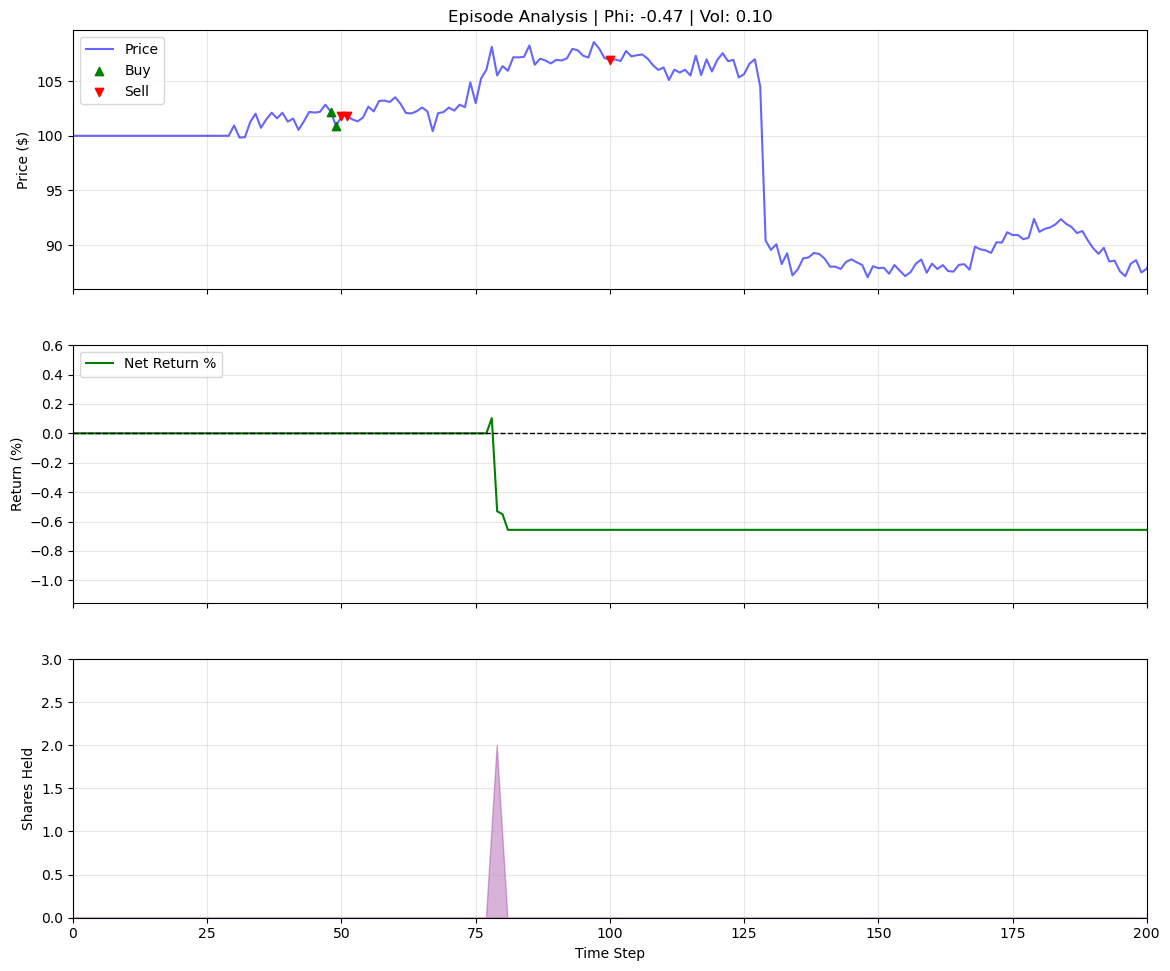

In [10]:
import numpy as np
import time
from stable_baselines3 import PPO

# 2. Initialize the Rigged Environment
# We use render_mode='human' so we can watch the crash in real-time
env_test = BlackSwanDirector(render_mode='human', num_steps=200)
obs, info = env_test.reset()

print(f"Testing Model: model on Black Swan Rigged Path...")

# 3. The Execution Loop
for step in range(env_test.num_steps):
    # The model looks at current cash, shares, and price history to decide
    action, _states = model.predict(obs, deterministic=True)
    
    # Apply the action to the environment
    obs, reward, terminated, truncated, info = env_test.step(action)
    
    # This calls your custom Matplotlib panes
    env_test.render()
    
    if terminated or truncated:
        print("Episode Finished.")
        break